In [1]:
import glob
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy import stats
from scipy.stats import pearsonr, spearmanr

In [2]:
ds = xr.open_dataset("../disdata/gfas_data/gfas_pm25_2223.nc")

print(ds)
print(ds["pm2p5fire"].attrs)
print(ds.latitude.values[:5], ds.latitude.values[-5:])
print(ds.longitude.values[:5], ds.longitude.values[-5:])

<xarray.Dataset> Size: 9GB
Dimensions:     (valid_time: 365, latitude: 1800, longitude: 3600)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-07-02 ... 2023-07-01
  * latitude    (latitude) float64 14kB 89.95 89.85 89.75 ... -89.85 -89.95
  * longitude   (longitude) float64 29kB 0.05 0.15 0.25 ... 359.8 359.9 359.9
Data variables:
    pm2p5fire   (valid_time, latitude, longitude) float32 9GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-14T12:43 GRIB to CDM+CF via cfgrib-0.9.1...
{'GRIB_paramId': np.int64(210087), 'GRIB_dataType': 'ga', 'GRIB_numberOfPoints': np.int64(6480000), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'avg', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRela

## Combining all the .nc files

In [3]:
files = sorted(glob.glob("../disdata/gfas_data/gfas_pm25_*.nc"))

def subset_region(ds):
    return ds.sel(latitude=slice(-36, -39), longitude=slice(286, 289))

In [4]:
combined = xr.open_mfdataset(
    files,
    combine="by_coords",
    preprocess=subset_region,
    chunks="auto"
)

pm25 = combined["pm2p5fire"]
print(pm25)

<xarray.DataArray 'pm2p5fire' (valid_time: 7305, latitude: 30, longitude: 30)> Size: 26MB
dask.array<concatenate, shape=(7305, 30, 30), dtype=float32, chunksize=(134, 30, 30), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 58kB 2003-07-02 ... 2023-07-01
  * latitude    (latitude) float64 240B -36.05 -36.15 -36.25 ... -38.85 -38.95
  * longitude   (longitude) float64 240B 286.0 286.1 286.2 ... 288.7 288.8 288.9
Attributes: (12/33)
    GRIB_paramId:                             210087
    GRIB_dataType:                            ga
    GRIB_numberOfPoints:                      6480000
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_units:                               kg m**-2 s**-1
    long_name:                                Wildfire flux of Particulate Ma...
    units:                     

In [5]:
# Sort, remove duplicates, remove the one stray day at the end of 2023
pm25 = pm25.sortby("valid_time")
pm25 = pm25.drop_duplicates(dim="valid_time")

# remove the single stray day that starts fire year 2023 with only 1 day of data
pm25 = pm25.sel(valid_time=pm25.valid_time != np.datetime64("2023-07-01"))

print("Date range:", pm25.valid_time.min().values, "to", pm25.valid_time.max().values)
print("Total days:", pm25.valid_time.size)

Date range: 2003-07-02T00:00:00.000000000 to 2023-06-30T00:00:00.000000000
Total days: 7304


In [6]:
# Assign fire years and check for completeness 
times = pd.to_datetime(pm25.valid_time.values)
fire_year_start = np.where(times.month >= 7, times.year, times.year - 1)
pm25 = pm25.assign_coords(fire_year_start=("valid_time", fire_year_start))

check = []
for fy, grp in pm25.groupby("fire_year_start"):
    t = pd.to_datetime(grp.valid_time.values)
    check.append({"fire_year_start": fy, "start": t.min(), "end": t.max(), "n_days": len(t)})

check_df = pd.DataFrame(check).sort_values("fire_year_start")
print(check_df)

    fire_year_start      start        end  n_days
0              2003 2003-07-02 2004-06-30     365
1              2004 2004-07-01 2005-06-30     365
2              2005 2005-07-01 2006-06-30     365
3              2006 2006-07-01 2007-06-30     365
4              2007 2007-07-01 2008-06-30     366
5              2008 2008-07-01 2009-06-30     365
6              2009 2009-07-01 2010-06-30     365
7              2010 2010-07-01 2011-06-30     365
8              2011 2011-07-01 2012-06-30     366
9              2012 2012-07-01 2013-06-30     365
10             2013 2013-07-01 2014-06-30     365
11             2014 2014-07-01 2015-06-30     365
12             2015 2015-07-01 2016-06-30     366
13             2016 2016-07-01 2017-06-30     365
14             2017 2017-07-01 2018-06-30     365
15             2018 2018-07-01 2019-06-30     365
16             2019 2019-07-01 2020-06-30     366
17             2020 2020-07-01 2021-06-30     365
18             2021 2021-07-01 2022-06-30     365


## Convert Units

In [7]:
# Convert flux from kg/m2/s to mass kg/day/cell
R_earth = 6371000  # metres
dlat_rad = np.radians(0.1)
dlon_rad = np.radians(0.1)

lat_rad = np.radians(pm25.latitude.values)
cell_area = (R_earth ** 2) * dlat_rad * dlon_rad * np.cos(lat_rad)  # m^2, varies by latitude row

cell_area_da = xr.DataArray(cell_area, coords={"latitude": pm25.latitude}, dims="latitude")

seconds_per_day = 86400
daily_mass = pm25 * cell_area_da * seconds_per_day  # kg/day per cell

In [8]:
# Aggregate to fire-year totals - Daily Mass Sums 
annual_totals = daily_mass.sum(dim=["latitude", "longitude"]).groupby("fire_year_start").sum(dim="valid_time")

df = annual_totals.to_dataframe(name="pm25_kg_total").reset_index().sort_values("fire_year_start")
print(df)

df.to_csv("../outputs/gfas_pm25_annual_totals.csv", index=False)

    fire_year_start  pm25_kg_total
0              2003   1.994396e+07
1              2004   1.496492e+07
2              2005   1.699186e+07
3              2006   2.761531e+07
4              2007   2.469729e+07
5              2008   2.283347e+07
6              2009   2.039989e+07
7              2010   1.739813e+07
8              2011   2.356574e+07
9              2012   1.485922e+07
10             2013   2.290983e+07
11             2014   3.510075e+07
12             2015   2.574919e+07
13             2016   4.328219e+07
14             2017   1.559331e+07
15             2018   2.258700e+07
16             2019   2.161700e+07
17             2020   1.450513e+07
18             2021   2.453972e+07
19             2022   1.238241e+08


## Inspect GFAS Trends

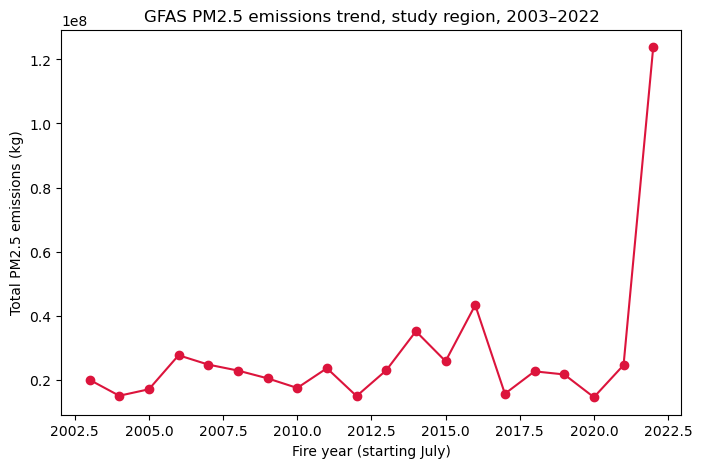

Trend: no trend
p-value: 0.3468
Tau: 0.1579
Sen's slope: 275953.91 kg/year
Significant at 0.05: False


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["fire_year_start"], df["pm25_kg_total"], marker="o", color="crimson")
ax.set_xlabel("Fire year (starting July)")
ax.set_ylabel("Total PM2.5 emissions (kg)")
ax.set_title("GFAS PM2.5 emissions trend, study region, 2003–2022")
plt.savefig("../outputs/gfas_pm25_trend.png", bbox_inches="tight", dpi=150)
plt.show()

result = mk.original_test(df["pm25_kg_total"])

print(f"Trend: {result.trend}")
print(f"p-value: {float(result.p):.4f}")
print(f"Tau: {float(result.Tau):.4f}")
print(f"Sen's slope: {float(result.slope):.2f} kg/year")
print(f"Significant at 0.05: {result.h}")

In [10]:
# Inspecting the 2022-2023 result
final_fy = df["fire_year_start"].max()

fy_data = daily_mass.where(pm25.fire_year_start == final_fy, drop=True)
monthly = fy_data.sum(dim=["latitude", "longitude"]).resample(valid_time="ME").sum()

monthly_df = monthly.to_dataframe(name="pm25_kg_monthly").reset_index()
print(monthly_df)

daily_fy = fy_data.sum(dim=["latitude", "longitude"])
daily_df = daily_fy.to_dataframe(name="pm25_kg_daily").reset_index().sort_values("pm25_kg_daily", ascending=False)
print(daily_df.head(10))

   valid_time  pm25_kg_monthly
0  2022-07-31     0.000000e+00
1  2022-08-31     1.756960e+05
2  2022-09-30     7.254299e+05
3  2022-10-31     4.160314e+05
4  2022-11-30     4.889528e+05
5  2022-12-31     2.400146e+06
6  2023-01-31     3.350998e+06
7  2023-02-28     1.026513e+08
8  2023-03-31     5.359382e+06
9  2023-04-30     4.708802e+06
10 2023-05-31     2.817508e+06
11 2023-06-30     7.298191e+05
    valid_time  fire_year_start  pm25_kg_daily
218 2023-02-04             2022   3.067611e+07
219 2023-02-05             2022   2.790034e+07
221 2023-02-07             2022   7.677590e+06
222 2023-02-08             2022   7.245449e+06
223 2023-02-09             2022   5.498350e+06
220 2023-02-06             2022   5.100554e+06
217 2023-02-03             2022   4.056546e+06
224 2023-02-10             2022   2.649475e+06
225 2023-02-11             2022   1.975808e+06
226 2023-02-12             2022   1.825471e+06


## GFAS vs. FINN - Daily Sum Comparisons

In [11]:
# Build the GFAS daily total series (across all years) 
gfas_daily = daily_mass.sum(dim=["latitude", "longitude"])
gfas_daily_df = gfas_daily.to_dataframe(name="gfas_pm25_kg_day").reset_index()
gfas_daily_df = gfas_daily_df.rename(columns={"valid_time": "date"})
gfas_daily_df["date"] = pd.to_datetime(gfas_daily_df["date"])

gfas_daily_df.to_csv("../outputs/gfas_pm25_daily_totals.csv", index=False)

print(gfas_daily_df.head())
print(gfas_daily_df.shape)

        date  fire_year_start  gfas_pm25_kg_day
0 2003-07-02             2003          0.000000
1 2003-07-03             2003       2676.762297
2 2003-07-04             2003       7090.494032
3 2003-07-05             2003          0.000000
4 2003-07-06             2003          0.000000
(7304, 3)


In [12]:
# Load in the FINN daily data to this notebook 
finn_daily_df = pd.read_csv("../outputs/finn_pm25_daily_core.csv")
finn_daily_df["date"] = pd.to_datetime(finn_daily_df["date"])
print(finn_daily_df.head())
print(finn_daily_df.shape)

        date  PM25_kg_day_sum  PM25_kg_day_mean  fire_year
0 2003-07-01           0.0000          0.000000       2003
1 2003-07-02        5230.0474          5.811164       2003
2 2003-07-03       17039.8630         18.933182       2003
3 2003-07-04           0.0000          0.000000       2003
4 2003-07-05           0.0000          0.000000       2003
(7305, 4)


In [13]:
# Merge the 2 based on date
merged = pd.merge(
    finn_daily_df[["date", "PM25_kg_day_sum"]],
    gfas_daily_df[["date", "gfas_pm25_kg_day"]],
    on="date",
    how="inner"
)
print(f"Merged rows: {merged.shape[0]}")
print(f"FINN date range: {finn_daily_df['date'].min()} to {finn_daily_df['date'].max()}")
print(f"GFAS date range: {gfas_daily_df['date'].min()} to {gfas_daily_df['date'].max()}")
print(f"Merged date range: {merged['date'].min()} to {merged['date'].max()}")

Merged rows: 7304
FINN date range: 2003-07-01 00:00:00 to 2023-06-30 00:00:00
GFAS date range: 2003-07-02 00:00:00 to 2023-06-30 00:00:00
Merged date range: 2003-07-02 00:00:00 to 2023-06-30 00:00:00


In [ ]:
# daily comparison 
daily_pearson_r, daily_pearson_p = pearsonr(merged["PM25_kg_day_sum"], merged["gfas_pm25_kg_day"])
daily_spearman_r, daily_spearman_p = spearmanr(merged["PM25_kg_day_sum"], merged["gfas_pm25_kg_day"])

finn_daily_trend = mk.original_test(merged["PM25_kg_day_sum"].values)
gfas_daily_trend = mk.original_test(merged["gfas_pm25_kg_day"].values)

print("=== FINN vs GFAS: daily PM2.5 (kg/day) ===")
print(f"n = {len(merged)} days")
print(f"Pearson  r = {daily_pearson_r:.3f} (p = {daily_pearson_p:.4f})")
print(f"Spearman r = {daily_spearman_r:.3f} (p = {daily_spearman_p:.4f})")
print(f"FINN  — mean: {merged['PM25_kg_day_sum'].mean():,.0f} kg, median: {merged['PM25_kg_day_sum'].median():,.0f} kg, max: {merged['PM25_kg_day_sum'].max():,.0f} kg")
print(f"GFAS  — mean: {merged['gfas_pm25_kg_day'].mean():,.0f} kg, median: {merged['gfas_pm25_kg_day'].median():,.0f} kg, max: {merged['gfas_pm25_kg_day'].max():,.0f} kg")
print(f"Zero-value days — FINN: {(merged['PM25_kg_day_sum'] == 0).sum()}, GFAS: {(merged['gfas_pm25_kg_day'] == 0).sum()}")
print(f"\nFINN daily trend  — {finn_daily_trend.trend}, p = {finn_daily_trend.p:.4f}, Sen's slope = {finn_daily_trend.slope:.4e} kg/day per day")
print(f"GFAS daily trend  — {gfas_daily_trend.trend}, p = {gfas_daily_trend.p:.4f}, Sen's slope = {gfas_daily_trend.slope:.4e} kg/day per day")

In [ ]:
# Investigating the GFAS 0.0 slope and p-value
print(f"Tau: {gfas_daily_trend.Tau}")
print(f"z-statistic: {gfas_daily_trend.z}")
print(f"S: {gfas_daily_trend.s}")
print(f"var(S): {gfas_daily_trend.var_s}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(merged["PM25_kg_day_sum"], merged["gfas_pm25_kg_day"], alpha=0.4, s=10)
axes[0].set_xlabel("FINN daily PM2.5 (kg)")
axes[0].set_ylabel("GFAS daily PM2.5 (kg)")
axes[0].set_title(f"FINN vs GFAS daily PM2.5\nPearson r={daily_pearson_r:.3f}, Spearman r={daily_spearman_r:.3f}")
axes[0].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
axes[0].set_axisbelow(True)  # ensures grid sits behind the data

axes[1].plot(merged["date"], merged["PM25_kg_day_sum"], label="FINN", alpha=0.7, linewidth=0.8)
axes[1].plot(merged["date"], merged["gfas_pm25_kg_day"], label="GFAS", alpha=0.7, linewidth=0.8, color='crimson')
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily PM2.5 (kg)")
axes[1].set_title("Daily PM2.5 time series, FINN vs GFAS")
axes[1].legend()
axes[1].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
axes[1].set_axisbelow(True)  # ensures grid sits behind the data, not on top of it

plt.tight_layout()
plt.savefig("../outputs/finn_gfas_daily_comparison.png", bbox_inches="tight", dpi=400)
plt.show()

In [ ]:
print("FINN zero-value days:", (merged["PM25_kg_day_sum"] == 0).sum(), "out of", len(merged))
print("GFAS zero-value days:", (merged["gfas_pm25_kg_day"] == 0).sum(), "out of", len(merged))
print("\nFINN near-zero (<1 kg) days:", (merged["PM25_kg_day_sum"] < 1).sum())
print("GFAS near-zero (<1 kg) days:", (merged["gfas_pm25_kg_day"] < 1).sum())
print("\nFINN min/max:", merged["PM25_kg_day_sum"].min(), merged["PM25_kg_day_sum"].max())
print("GFAS min/max:", merged["gfas_pm25_kg_day"].min(), merged["gfas_pm25_kg_day"].max())

## GFAS vs. FINN - Monthly Sum Comparisons

In [ ]:
# Aggregating both to get monthly totals
merged["year_month"] = merged["date"].dt.to_period("M")

monthly = merged.groupby("year_month").agg(
    finn_pm25_kg_month=("PM25_kg_day_sum", "sum"),
    gfas_pm25_kg_month=("gfas_pm25_kg_day", "sum")
).reset_index()

monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

monthly.to_csv("../outputs/gfas_pm25_monthly_totals.csv", index=False)

print(monthly.head())
print(monthly.shape)

In [ ]:
# Monthly correlation tests
pearson_r_m, pearson_p_m = stats.pearsonr(monthly["finn_pm25_kg_month"], monthly["gfas_pm25_kg_month"])
spearman_r_m, spearman_p_m = stats.spearmanr(monthly["finn_pm25_kg_month"], monthly["gfas_pm25_kg_month"])

print(f"Monthly Pearson r: {pearson_r_m:.4f}, p-value: {pearson_p_m:.4g}")
print(f"Monthly Spearman r: {spearman_r_m:.4f}, p-value: {spearman_p_m:.4g}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(monthly["finn_pm25_kg_month"], monthly["gfas_pm25_kg_month"], alpha=0.6, s=20)
axes[0].set_xlabel("FINN monthly PM2.5 (kg)")
axes[0].set_ylabel("GFAS monthly PM2.5 (kg)")
axes[0].set_title(f"FINN vs GFAS monthly PM2.5\nPearson r={pearson_r_m:.3f}, Spearman r={spearman_r_m:.3f}")
axes[0].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
axes[0].set_axisbelow(True)  # ensures grid sits behind the data, not on top of it

axes[1].plot(monthly["year_month"], monthly["finn_pm25_kg_month"], label="FINN", alpha=0.8)
axes[1].plot(monthly["year_month"], monthly["gfas_pm25_kg_month"], label="GFAS", alpha=0.8, color='crimson')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Monthly PM2.5 (kg)")
axes[1].set_title("Monthly PM2.5 time series, FINN vs GFAS")
axes[1].legend()
axes[1].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
axes[1].set_axisbelow(True)  # ensures grid sits behind the data, not on top of it

plt.tight_layout()
plt.savefig("../outputs/finn_gfas_monthly_comparison.png", bbox_inches="tight", dpi=400)
plt.show()

In [ ]:
monthly_sorted = monthly.sort_values("finn_pm25_kg_month", ascending=False)
print(monthly_sorted.head(5))

## Percentage Difference/Ratio

In [ ]:
merged = pd.merge(
    finn_daily_df[["date", "PM25_kg_day_sum"]],
    gfas_daily_df[["date", "gfas_pm25_kg_day"]],
    on="date",
    how="inner"
)
print(f"Merged rows: {merged.shape[0]}")
print(f"FINN date range: {finn_daily_df['date'].min()} to {finn_daily_df['date'].max()}")
print(f"GFAS date range: {gfas_daily_df['date'].min()} to {gfas_daily_df['date'].max()}")
print(f"Merged date range: {merged['date'].min()} to {merged['date'].max()}")

In [ ]:
merged["fire_year_start"] = np.where(
    merged["date"].dt.month >= 7,
    merged["date"].dt.year,
    merged["date"].dt.year - 1
)

In [ ]:
days_per_year = merged.groupby("fire_year_start").size()
print(days_per_year)

In [ ]:
# Aggregate fire year totals
annual_compare = merged.groupby("fire_year_start").agg(
    finn_pm25_kg_total=("PM25_kg_day_sum", "sum"),
    gfas_pm25_kg_total=("gfas_pm25_kg_day", "sum")
).reset_index()

print(annual_compare)

In [ ]:
# Ratio and percentage difference 
annual_compare["ratio_finn_gfas"] = annual_compare["finn_pm25_kg_total"] / annual_compare["gfas_pm25_kg_total"]
annual_compare["pct_diff"] = (annual_compare["finn_pm25_kg_total"] - annual_compare["gfas_pm25_kg_total"]) / annual_compare["gfas_pm25_kg_total"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(annual_compare["fire_year_start"], annual_compare["pct_diff"], color="tab:purple", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Fire year (starting July)")
ax.set_ylabel("Percentage difference (FINN vs GFAS, %)")
ax.set_title("FINN relative to GFAS, annual PM2.5 emissions")
plt.savefig("../outputs/finn_gfas_pct_diff_annual.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
print(f"Median annual FINN/GFAS ratio: {annual_compare['ratio_finn_gfas'].median():.2f}") 
print(f"Median annual percentage difference: {annual_compare['pct_diff'].median():.1f}%")

## Seasonal Comparison GFAS vs. FINN

In [ ]:
# extract calendar month and compute mean plus variability by month across all years
merged["month"] = merged["date"].dt.month

seasonal = merged.groupby("month").agg(
    finn_mean=("PM25_kg_day_sum", "mean"),
    finn_std=("PM25_kg_day_sum", "std"),
    gfas_mean=("gfas_pm25_kg_day", "mean"),
    gfas_std=("gfas_pm25_kg_day", "std")
).reset_index()

print(seasonal)

In [ ]:
# Reorder months to follow southern hemisphere fire year convention 
fire_year_order = [7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
month_labels = ["Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun"]

seasonal["month"] = pd.Categorical(seasonal["month"], categories=fire_year_order, ordered=True)
seasonal = seasonal.sort_values("month").reset_index(drop=True)
seasonal["month_label"] = month_labels

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(seasonal))
ax.plot(x, seasonal["finn_mean"], marker="o", label="FINN", color="dimgrey")
ax.fill_between(
    x,
    seasonal["finn_mean"] - seasonal["finn_std"],
    seasonal["finn_mean"] + seasonal["finn_std"],
    alpha=0.15, color="dimgrey", label="FINN ± 1 SD"
)
ax.plot(x, seasonal["gfas_mean"], marker="o", label="GFAS", color="crimson")
ax.fill_between(
    x,
    seasonal["gfas_mean"] - seasonal["gfas_std"],
    seasonal["gfas_mean"] + seasonal["gfas_std"],
    alpha=0.15, color="crimson", label="GFAS ± 1 SD"
)
ax.set_xticks(x)
ax.set_xticklabels(seasonal["month_label"])
ax.set_xlabel("Month (fire year order)")
ax.set_ylabel("Mean daily PM2.5 emissions (kg)")
ax.set_title("Seasonal cycle of PM2.5 emissions, FINN vs GFAS (2003–2022 mean)")
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/finn_gfas_seasonal_cycle.png", bbox_inches="tight", dpi=400)
plt.show()

# shaded area is the standard deviation band around FINN's mean daily emissions for each month

In [ ]:
# Poster version of the FINN vs GFAS seasonal cycle figure 
poster_fontsize = {
    "title": 20,
    "label": 17,
    "tick": 16,
    "legend": 14,
}

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(seasonal))

ax.plot(x, seasonal["finn_mean"], marker="o", label="FINN", color="dimgrey", linewidth=2, markersize=7)
ax.fill_between(
    x,
    seasonal["finn_mean"] - seasonal["finn_std"],
    seasonal["finn_mean"] + seasonal["finn_std"],
    alpha=0.15, color="dimgrey", label="FINN ± 1 SD"
)
ax.plot(x, seasonal["gfas_mean"], marker="o", label="GFAS", color="crimson", linewidth=2, markersize=7)
ax.fill_between(
    x,
    seasonal["gfas_mean"] - seasonal["gfas_std"],
    seasonal["gfas_mean"] + seasonal["gfas_std"],
    alpha=0.15, color="crimson", label="GFAS ± 1 SD"
)

ax.set_xticks(x)
ax.set_xticklabels(seasonal["month_label"], fontsize=poster_fontsize["tick"])
ax.set_xlabel("Month (fire year order)", fontsize=poster_fontsize["label"])
ax.set_ylabel("Mean daily PM2.5 emissions (kg)", fontsize=poster_fontsize["label"])
ax.set_title("Seasonal cycle of PM2.5 emissions, FINN vs GFAS (2003–2022 mean)", fontsize=poster_fontsize["title"])
ax.tick_params(axis="y", labelsize=poster_fontsize["tick"])
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)
ax.legend(fontsize=poster_fontsize["legend"])

plt.tight_layout()
plt.savefig("../outputs/finn_gfas_seasonal_cycle_poster.png", bbox_inches="tight", dpi=400)
plt.show()

In [ ]:
# Normalise each product to its own peak to compare timing/shape of the cycle independent of magntidue differences
seasonal["finn_normalised"] = seasonal["finn_mean"] / seasonal["finn_mean"].max()
seasonal["gfas_normalised"] = seasonal["gfas_mean"] / seasonal["gfas_mean"].max()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, seasonal["finn_normalised"], marker="o", label="FINN (normalised)", color='dimgrey')
ax.plot(x, seasonal["gfas_normalised"], marker="o", label="GFAS (normalised)", color='crimson')
ax.set_xticks(x)
ax.set_xticklabels(seasonal["month_label"])
ax.set_xlabel("Month (fire year order)")
ax.set_ylabel("Fraction of peak month")
ax.set_title("Normalised seasonal cycle shape, FINN vs GFAS")
ax.legend()
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it

plt.tight_layout()
plt.savefig("../outputs/finn_gfas_seasonal_cycle_normalised.png", bbox_inches="tight", dpi=150)
plt.show()

## GFAS vs FSL

In [ ]:
print(df.head())  # GFAS annual totals dataframe, columns: fire_year_start, pm25_kg_total
print(df["fire_year_start"].dtype)

In [ ]:
gfas_core_annual = df.rename(columns={
    "fire_year_start": "fire_year",
    "pm25_kg_total": "PM25_kg_annual"
})
print(gfas_core_annual.head())
print(gfas_core_annual["fire_year"].dtype)

In [ ]:
fsl_m1 = pd.read_csv("../outputs/method1_results.csv")
fsl_m2 = pd.read_csv("../outputs/method2_results.csv")
fsl_m3 = pd.read_csv("../outputs/method3_percell_results.csv")

In [ ]:
fsl_m1["fire_year"] = fsl_m1["fire_year"].str.split("-").str[0].astype(int)
fsl_m2["fire_year"] = fsl_m2["fire_year_start"].str.split("-").str[0].astype(int)
fsl_m3["fire_year"] = fsl_m3["fire_year"].str.split("-").str[0].astype(int)

print(gfas_core_annual["fire_year"].dtype)
print(fsl_m1["fire_year"].dtype)
print(fsl_m2["fire_year"].dtype)
print(fsl_m3["fire_year"].dtype)

In [ ]:
# Merge GFAS and FSL Data
merged_fsl_gfas = gfas_core_annual.copy()
merged_fsl_gfas = merged_fsl_gfas.merge(fsl_m1[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "fsl_m1"}), on="fire_year", how="inner")
merged_fsl_gfas = merged_fsl_gfas.merge(fsl_m2[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "fsl_m2"}), on="fire_year", how="inner")
merged_fsl_gfas = merged_fsl_gfas.merge(fsl_m3[["fire_year", "fsl_p90_median"]].rename(columns={"fsl_p90_median": "fsl_m3"}), on="fire_year", how="inner")

print(merged_fsl_gfas.head())
print(merged_fsl_gfas.shape)

In [ ]:
fsl_methods = [
    ("fsl_m1", "Method 1 (first–last fire date)", "#5B7FBF"),
    ("fsl_m2", "Method 2 (5th–95th pct burned area)", "#F77F00"),
    ("fsl_m3", "Method 3 (FWI per-cell threshold)", "#43AA8B"),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, (fsl_col, fsl_label, fsl_colour) in zip(axes, fsl_methods):
    ax2 = ax.twinx()
    ax.plot(merged_fsl_gfas["fire_year"], merged_fsl_gfas["PM25_kg_annual"],
            marker="o", color="crimson", linewidth=1.5, label="PM₂.₅ emissions")
    ax2.plot(merged_fsl_gfas["fire_year"], merged_fsl_gfas[fsl_col],
             marker="s", color=fsl_colour, linewidth=1.5, linestyle="--", label=fsl_label)
    ax.set_ylabel("PM₂.₅ (kg/fire year)", color="crimson")
    ax2.set_ylabel("FSL (days)", color=fsl_colour)
    ax.tick_params(axis="y", labelcolor="crimson")
    ax2.tick_params(axis="y", labelcolor=fsl_colour)
    ax.set_title(f"GFAS PM₂.₅ vs {fsl_label}")
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

# build fire-year-range labels (e.g. 2003-2004) and show every year on the x-axis
x_vals = merged_fsl_gfas["fire_year"].values
fire_year_labels = [f"{yr}-{yr+1}" for yr in x_vals]
axes[-1].set_xticks(x_vals)
axes[-1].set_xticklabels(fire_year_labels, rotation=75, ha="right")
axes[-1].set_xlabel("Fire year")

fig.suptitle("GFAS PM₂.₅ Emissions vs Fire Season Length", fontsize=18)
plt.tight_layout()
plt.savefig("../outputs/fig10_gfas_pm25_vs_fsl.png", dpi=400, bbox_inches="tight")
plt.show()

In [ ]:
# Poster version of the GFAS PM2.5 vs FSL figure (larger fonts)
poster_fontsize = {
    "suptitle": 24,
    "title": 18,
    "label": 17,
    "tick": 15,
    "legend": 14,
}

fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

for ax, (fsl_col, fsl_label, fsl_colour) in zip(axes, fsl_methods):
    ax2 = ax.twinx()
    ax.plot(merged_fsl_gfas["fire_year"], merged_fsl_gfas["PM25_kg_annual"],
            marker="o", color="crimson", linewidth=2, markersize=7, label="PM₂.₅ emissions")
    ax2.plot(merged_fsl_gfas["fire_year"], merged_fsl_gfas[fsl_col],
             marker="s", color=fsl_colour, linewidth=2, markersize=7, linestyle="--", label=fsl_label)
    ax.set_ylabel("PM₂.₅ (kg/fire year)", color="crimson", fontsize=poster_fontsize["label"])
    ax2.set_ylabel("FSL (days)", color=fsl_colour, fontsize=poster_fontsize["label"])
    ax.tick_params(axis="y", labelcolor="crimson", labelsize=poster_fontsize["tick"])
    ax2.tick_params(axis="y", labelcolor=fsl_colour, labelsize=poster_fontsize["tick"])
    ax.tick_params(axis="x", labelsize=poster_fontsize["tick"])
    ax.set_title(f"GFAS PM₂.₅ vs {fsl_label}", fontsize=poster_fontsize["title"])
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=poster_fontsize["legend"], loc="upper left")

# build fire-year-range labels (e.g. 2003-2004) and show every year on the x-axis
x_vals = merged_fsl_gfas["fire_year"].values
fire_year_labels = [f"{yr}-{yr+1}" for yr in x_vals]
axes[-1].set_xticks(x_vals)
axes[-1].set_xticklabels(fire_year_labels, rotation=75, ha="right", fontsize=poster_fontsize["tick"])
axes[-1].set_xlabel("Fire year", fontsize=poster_fontsize["label"])

fig.suptitle("GFAS PM₂.₅ Emissions vs Fire Season Length", fontsize=poster_fontsize["suptitle"])
plt.tight_layout()
plt.savefig("../outputs/fig10_gfas_pm25_vs_fsl_poster.png", dpi=400, bbox_inches="tight")
plt.show()

In [ ]:
# Correlations
from scipy import stats

for fsl_col, fsl_label in [
    ("fsl_m1", "Method 1 (first–last fire date)"),
    ("fsl_m2", "Method 2 (5th–95th pct burned area)"),
    ("fsl_m3", "Method 3 (FWI per-cell threshold)"),
]:
    x = merged_fsl_gfas["PM25_kg_annual"].values
    y = merged_fsl_gfas[fsl_col].values
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)
    print(f"\n--- GFAS PM₂.₅ vs {fsl_label} ---")
    print(f"  Pearson  r={r_p:.3f}, p={p_p:.4f}")
    print(f"  Spearman r={r_s:.3f}, p={p_s:.4f}")

In [ ]:
# annual sum comparison
annual_pearson_r, annual_pearson_p = pearsonr(annual_compare["finn_pm25_kg_total"], annual_compare["gfas_pm25_kg_total"])
annual_spearman_r, annual_spearman_p = spearmanr(annual_compare["finn_pm25_kg_total"], annual_compare["gfas_pm25_kg_total"])

finn_annual_trend = mk.original_test(annual_compare["finn_pm25_kg_total"].values)
gfas_annual_trend = mk.original_test(annual_compare["gfas_pm25_kg_total"].values)

print("=== FINN vs GFAS: annual PM2.5 sum (kg/fire year) ===")
print(f"n = {len(annual_compare)} years")
print(f"Pearson  r = {annual_pearson_r:.3f} (p = {annual_pearson_p:.4f})")
print(f"Spearman r = {annual_spearman_r:.3f} (p = {annual_spearman_p:.4f})")
print(f"FINN  — mean: {annual_compare['finn_pm25_kg_total'].mean():,.0f} kg, median: {annual_compare['finn_pm25_kg_total'].median():,.0f} kg")
print(f"GFAS  — mean: {annual_compare['gfas_pm25_kg_total'].mean():,.0f} kg, median: {annual_compare['gfas_pm25_kg_total'].median():,.0f} kg")
print(f"FINN/GFAS ratio — mean: {annual_compare['ratio_finn_gfas'].mean():.2f}, min: {annual_compare['ratio_finn_gfas'].min():.2f}, max: {annual_compare['ratio_finn_gfas'].max():.2f}")
print(f"Percent difference — mean: {annual_compare['pct_diff'].mean():.1f}%, min: {annual_compare['pct_diff'].min():.1f}%, max: {annual_compare['pct_diff'].max():.1f}%")
print(f"\nFINN annual trend — {finn_annual_trend.trend}, p = {finn_annual_trend.p:.4f}, Sen's slope = {finn_annual_trend.slope:.4e} kg/year per year")
print(f"GFAS annual trend — {gfas_annual_trend.trend}, p = {gfas_annual_trend.p:.4f}, Sen's slope = {gfas_annual_trend.slope:.4e} kg/year per year")